In [2]:
!pip install qiskit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.9 MB/s eta 0:00:00


In [3]:
!pip install qiskit_aer
!pip install matplotlib
!pip install scikit-learn
!pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 102.9 MB/s eta 0:00:00


In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator as IdealEstimator
from qiskit_aer.primitives import Estimator as NoisyEstimator
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt

In [5]:
# === CELL 2: ENHANCED FEATURE EXTRACTION FUNCTION ===
# NEW: Extracts 8 features per circuit instead of 3

def extract_circuit_features(qc, noisy_exp):
    """
    Extracts 8 structural features from a quantum circuit.

    V1 features (3): depth, cz_count, noisy_exp
    V2 features (8): depth, cz_count, noisy_exp, h_count, x_count,
                      cz_ratio, single_q_ratio, h_x_ratio

    The noisy_exp value is placed at index 2 for backward compatibility
    with the residual connection (which reads x[:, 2]).
    """
    ops = qc.count_ops()
    depth = qc.depth()
    cz_count = ops.get('cz', 0)
    h_count = ops.get('h', 0)
    x_count = ops.get('x', 0)

    total_gates = h_count + x_count + cz_count
    if total_gates == 0:
        total_gates = 1  # avoid division by zero

    cz_ratio = cz_count / total_gates
    single_q_ratio = (h_count + x_count) / total_gates
    h_x_ratio = h_count / max(x_count, 1)

    # IMPORTANT: noisy_exp stays at index 2 for the residual connection
    return [depth, cz_count, noisy_exp, h_count, x_count,
            cz_ratio, single_q_ratio, h_x_ratio]


In [6]:
# === CELL 3: GROVER CIRCUIT GENERATORS ===
# NEW: Functions to create structured Grover circuits for training

def make_grover_11():
    """Full 2-qubit Grover for target |11>: H-CZ(oracle)-H-X-CZ-X-H(diffusion)"""
    qc = QuantumCircuit(2, name='Grover_11')
    qc.h([0, 1])
    qc.cz(0, 1)         # Oracle marks |11>
    qc.h([0, 1])
    qc.x([0, 1])
    qc.cz(0, 1)
    qc.x([0, 1])
    qc.h([0, 1])
    return qc

def make_grover_00():
    """Full 2-qubit Grover for target |00>: X-H-CZ(oracle)-H-X-CZ-X-H-X"""
    qc = QuantumCircuit(2, name='Grover_00')
    qc.x([0, 1])
    qc.h([0, 1])
    qc.cz(0, 1)         # Oracle marks |00> (in X basis)
    qc.h([0, 1])
    qc.x([0, 1])
    qc.cz(0, 1)
    qc.x([0, 1])
    qc.h([0, 1])
    qc.x([0, 1])
    return qc

def make_double_grover():
    """Two iterations of Grover (deeper circuit)"""
    qc = QuantumCircuit(2, name='Double_Grover')
    for _ in range(2):
        qc.h([0, 1])
        qc.cz(0, 1)
        qc.h([0, 1])
        qc.x([0, 1])
        qc.cz(0, 1)
        qc.x([0, 1])
        qc.h([0, 1])
    return qc

def make_grover_with_rotations():
    """Grover |11> with extra single-qubit rotations before and after"""
    qc = QuantumCircuit(2, name='Grover_rotated')
    # Pre-rotation
    qc.x(0)
    qc.h(1)
    # Standard Grover |11>
    qc.h([0, 1])
    qc.cz(0, 1)
    qc.h([0, 1])
    qc.x([0, 1])
    qc.cz(0, 1)
    qc.x([0, 1])
    qc.h([0, 1])
    # Post-rotation
    qc.h(0)
    qc.x(1)
    return qc

def make_oracle_only():
    """Just the oracle portion: H-CZ"""
    qc = QuantumCircuit(2, name='Oracle_only')
    qc.h([0, 1])
    qc.cz(0, 1)
    return qc

def make_diffusion_only():
    """Just the diffusion operator: H-X-CZ-X-H"""
    qc = QuantumCircuit(2, name='Diffusion_only')
    qc.h([0, 1])
    qc.x([0, 1])
    qc.cz(0, 1)
    qc.x([0, 1])
    qc.h([0, 1])
    return qc

def generate_grover_basis_circuit(depth):
    """Generates a random circuit using ONLY the gates in the Grover diffusion operator."""
    qc = QuantumCircuit(2)
    available_gates = ['h0', 'h1', 'x0', 'x1', 'cz']

    for _ in range(depth):
        gate = np.random.choice(available_gates)
        if gate == 'h0': qc.h(0)
        elif gate == 'h1': qc.h(1)
        elif gate == 'x0': qc.x(0)
        elif gate == 'x1': qc.x(1)
        elif gate == 'cz': qc.cz(0, 1)
    return qc

In [7]:
# === CELL 4: DATASET GENERATION (SIMULATOR — V2) ===
# NEW: Mixed dataset with 400 random + 100 structured Grover circuits
# NEW: Enhanced 8-feature extraction
#
# NOTE: For IBM Cloud version, replace ideal_estimator and noisy_estimator
#       with the IBM backend versions, and adjust the estimator call syntax.

print("Initializing V2 Dataset Generation Pipeline...")

# 1. Setup the Simulators (same noise model as V1)
noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(depolarizing_error(0.05, 1), ['x', 'h'])
noise_model.add_all_qubit_quantum_error(depolarizing_error(0.1, 2), ['cx', 'cz'])

ideal_estimator = IdealEstimator()
noisy_estimator = NoisyEstimator(backend_options={"noise_model": noise_model})
observable = SparsePauliOp("ZZ")

X_data = []
Y_data = []

# --- Phase 1: Generate 400 random circuits ---
print("Phase 1: Generating 400 random circuits...")
for i in range(400):
    depth = np.random.randint(3, 11)
    qc = generate_grover_basis_circuit(depth)

    ideal_result = ideal_estimator.run([(qc, observable)]).result()
    ideal_exp = float(np.atleast_1d(ideal_result[0].data.evs)[0])

    noisy_result = noisy_estimator.run([qc], [observable]).result()
    noisy_exp = float(noisy_result.values[0])

    features = extract_circuit_features(qc, noisy_exp)
    X_data.append(features)
    Y_data.append([ideal_exp])

    if (i + 1) % 100 == 0:
        print(f"  [{i + 1}/400] random circuits processed...")

# --- Phase 2: Generate 100 structured Grover circuits ---
print("\nPhase 2: Generating 100 structured Grover circuits...")
grover_generators = [
    ("Grover |11>", make_grover_11),
    ("Grover |00>", make_grover_00),
    ("Double Grover", make_double_grover),
    ("Grover + Rotations", make_grover_with_rotations),
]

grover_count = 0
for name, gen_fn in grover_generators:
    for j in range(25):
        qc = gen_fn()

        ideal_result = ideal_estimator.run([(qc, observable)]).result()
        ideal_exp = float(np.atleast_1d(ideal_result[0].data.evs)[0])

        noisy_result = noisy_estimator.run([qc], [observable]).result()
        noisy_exp = float(noisy_result.values[0])

        features = extract_circuit_features(qc, noisy_exp)
        X_data.append(features)
        Y_data.append([ideal_exp])
        grover_count += 1

    print(f"  {name}: 25 circuits generated")

print(f"\nTotal circuits: {len(X_data)} ({len(X_data) - grover_count} random + {grover_count} Grover)")

X_tensor = torch.tensor(X_data, dtype=torch.float32)
Y_tensor = torch.tensor(Y_data, dtype=torch.float32)

print(f"\n--- V2 Dataset Ready ---")
print(f"Input Shape (X): {X_tensor.shape}")
print(f"Target Shape (Y): {Y_tensor.shape}")

torch.save(X_tensor, "QEM_X_features_V2.pt")
torch.save(Y_tensor, "QEM_Y_targets_V2.pt")
print("V2 tensors saved to disk!")


Initializing V2 Dataset Generation Pipeline...
Phase 1: Generating 400 random circuits...
  [100/400] random circuits processed...
  [200/400] random circuits processed...
  [300/400] random circuits processed...
  [400/400] random circuits processed...

Phase 2: Generating 100 structured Grover circuits...
  Grover |11>: 25 circuits generated
  Grover |00>: 25 circuits generated
  Double Grover: 25 circuits generated
  Grover + Rotations: 25 circuits generated

Total circuits: 500 (400 random + 100 Grover)

--- V2 Dataset Ready ---
Input Shape (X): torch.Size([500, 8])
Target Shape (Y): torch.Size([500, 1])
V2 tensors saved to disk!


In [10]:
# === CELL 5: DATA FUSION (V2) ===
# Same concept as V1 but with 8 circuit features → fused dim = 584

print("Stitching Tomography Data to V2 Circuit Executions...")

# Load the original tensors and the Choi numpy arrays
# CHANGE THESE PATHS to match your Google Drive structure
X_circuits = torch.load("QEM_X_features_V2.pt", weights_only=True)
Y_targets = torch.load("QEM_Y_targets_V2.pt", weights_only=True)

choi_H = np.load("/content/drive/MyDrive/IBM_CLOUD/ibm_choi_H.npy")
choi_X = np.load("/content/drive/MyDrive/IBM_CLOUD/ibm_choi_X.npy")
choi_CZ = np.load("/content/drive/MyDrive/IBM_CLOUD/ibm_choi_CZ.npy")

def process_choi(matrix):
    flattened = matrix.flatten()
    return np.concatenate([np.real(flattened), np.imag(flattened)])

flat_H = process_choi(choi_H)
flat_X = process_choi(choi_X)
flat_CZ = process_choi(choi_CZ)

hardware_footprint = np.concatenate([flat_H, flat_X, flat_CZ])
hardware_tensor = torch.tensor(hardware_footprint, dtype=torch.float32)

print(f"Hardware Footprint Size: {hardware_tensor.shape[0]} features")

hardware_batch = hardware_tensor.unsqueeze(0).expand(X_circuits.shape[0], -1)
X_fused = torch.cat((X_circuits, hardware_batch), dim=1)

print(f"\n--- V2 Fused Dataset ---")
print(f"Circuit Features: {X_circuits.shape[1]}")
print(f"Hardware Features: {hardware_tensor.shape[0]}")
print(f"Fused Shape: {X_fused.shape} ({X_circuits.shape[1]} + {hardware_tensor.shape[0]})")

torch.save(X_fused, "QEM_X_Fused_V2.pt")
print("V2 fused dataset saved!")



Stitching Tomography Data to V2 Circuit Executions...
Hardware Footprint Size: 576 features

--- V2 Fused Dataset ---
Circuit Features: 8
Hardware Features: 576
Fused Shape: torch.Size([500, 584]) (8 + 576)
V2 fused dataset saved!


In [22]:
# === CELL 6: V3 ARCHITECTURE (Simplified ResNet) ===
class StableResidualMLP(nn.Module):
    def __init__(self, input_dim=8, hidden_dim=64, dropout=0.3):
        super(StableResidualMLP, self).__init__()

        # Shallow, wide network optimized for small tabular data
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.SiLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim // 2, 1)
        )

        # Initialize final layer weights to near-zero so it starts by predicting 0 correction
        nn.init.normal_(self.network[-1].weight, mean=0.0, std=0.01)
        nn.init.constant_(self.network[-1].bias, 0.0)

    def forward(self, x):
        # Isolate the raw noisy measurement (index 2)
        raw_noisy = x[:, 2].unsqueeze(1)

        # Predict the residual correction
        correction = self.network(x)

        # Bound the correction using tanh to prevent massive hallucinations (assuming exp values are [-1, 1])
        # This acts as a safety net against the -1400% errors
        bounded_correction = torch.tanh(correction) * 0.5

        return raw_noisy + bounded_correction

In [23]:
# === CELL 7: TRAINING FUNCTION (V3) ===
def train_model_v3(model, dataloader, epochs=250, lr=0.005, weight_decay=1e-3):
    print(f"\n--- V3 Training Loop ({epochs} Epochs, robust weight decay) ---")

    # Use Huber Loss instead of MSE to ignore massive outliers during training
    criterion = nn.HuberLoss(delta=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=20, factor=0.5)

    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for batch_X, batch_Y in dataloader:
            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_Y)
            loss.backward()

            # Gradient clipping for extreme stability
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            epoch_loss += loss.item()

        scheduler.step(epoch_loss)

        if (epoch + 1) % 50 == 0:
            print(f"  Epoch [{epoch+1}/{epochs}] - Huber Loss: {epoch_loss / len(dataloader):.6f}")

    print("V3 Training Complete!")
    return model

In [24]:
# === CELL 8: MAIN EXECUTION (V3) ===
# We are ignoring the fused dataset and strictly using the 8 circuit features
X_circuits = torch.load("QEM_X_features_V2.pt", weights_only=True)
Y_targets = torch.load("QEM_Y_targets_V2.pt", weights_only=True)

print(f"Loaded V3 dataset (Circuit features only): X={X_circuits.shape}, Y={Y_targets.shape}")

# Normalize features (Crucial for MLPs)
# We do NOT normalize the noisy expectation value at index 2, as it acts as our baseline
X_normalized = X_circuits.clone()
for col in [0, 1, 3, 4, 5, 6, 7]:
    mean = X_normalized[:, col].mean()
    std = X_normalized[:, col].std()
    X_normalized[:, col] = (X_normalized[:, col] - mean) / (std + 1e-8)

dataset = TensorDataset(X_normalized, Y_targets)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

model_v3 = StableResidualMLP(input_dim=8)
trained_model_v3 = train_model_v3(model_v3, dataloader)

# Re-assign X_all and Y_all so your downstream Validation tests (Cells 9-15) run cleanly on V3
X_all = X_normalized
Y_all = Y_targets

Loaded V3 dataset (Circuit features only): X=torch.Size([500, 8]), Y=torch.Size([500, 1])

--- V3 Training Loop (250 Epochs, robust weight decay) ---
  Epoch [50/250] - Huber Loss: 0.003055
  Epoch [100/250] - Huber Loss: 0.002709
  Epoch [150/250] - Huber Loss: 0.002380
  Epoch [200/250] - Huber Loss: 0.002729
  Epoch [250/250] - Huber Loss: 0.001912
V3 Training Complete!


In [14]:
# ============================================================================
# V2 VALIDATION TESTS
# ============================================================================
# Below are the updated validation tests adapted for V2.
# Each test section is a separate cell.
# ============================================================================


# === CELL 9: V2 TEST 1 — Proper Train/Test Split ===

print("="*70)
print("V2 TEST 1: PROPER TRAIN/TEST SPLIT EVALUATION")
print("="*70)

X_train, X_test, Y_train, Y_test = train_test_split(
    X_all.numpy(), Y_all.numpy(), test_size=0.2, random_state=42
)
X_train_t = torch.tensor(X_train, dtype=torch.float32)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
Y_test_t = torch.tensor(Y_test, dtype=torch.float32)

print(f"Training samples: {len(X_train_t)}")
print(f"Test samples:     {len(X_test_t)}")

# Train fresh model on training data only
model_split = HardwareAwareAttentionNetV2(input_dim=X_train_t.shape[1])
train_dataset = TensorDataset(X_train_t, Y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

optimizer = optim.Adam(model_split.parameters(), lr=0.002, weight_decay=1e-4)
criterion = nn.MSELoss()

print("\nTraining V2 on 80% split...")
model_split.train()
for epoch in range(200):
    epoch_loss = 0
    for batch_X, batch_Y in train_loader:
        optimizer.zero_grad()
        preds = model_split(batch_X)
        loss = criterion(preds, batch_Y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    if (epoch + 1) % 50 == 0:
        print(f"  Epoch [{epoch+1}/200] - Loss: {epoch_loss / len(train_loader):.6f}")

# Evaluate on BOTH sets
model_split.eval()
with torch.no_grad():
    train_preds = model_split(X_train_t).numpy().flatten()
    test_preds = model_split(X_test_t).numpy().flatten()

train_true = Y_train_t.numpy().flatten()
test_true = Y_test_t.numpy().flatten()
train_noisy = X_train_t[:, 2].numpy()
test_noisy = X_test_t[:, 2].numpy()

print("\n--- TRAINING SET METRICS ---")
print(f"  MAE:  {mean_absolute_error(train_true, train_preds):.6f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(train_true, train_preds)):.6f}")
print(f"  R^2:  {r2_score(train_true, train_preds):.4f}")

print("\n--- TEST SET METRICS (UNSEEN DATA) ---")
test_mae = mean_absolute_error(test_true, test_preds)
test_rmse = np.sqrt(mean_squared_error(test_true, test_preds))
test_r2 = r2_score(test_true, test_preds)
print(f"  MAE:  {test_mae:.6f}")
print(f"  RMSE: {test_rmse:.6f}")
print(f"  R^2:  {test_r2:.4f}")

raw_errors = np.abs(test_true - test_noisy)
mitigated_errors = np.abs(test_true - test_preds)
improvements = []
for i in range(len(test_true)):
    if raw_errors[i] > 1e-6:
        imp = ((raw_errors[i] - mitigated_errors[i]) / raw_errors[i]) * 100
        improvements.append(imp)

test_true_flat = test_true
test_noisy_flat = test_noisy

print(f"\n--- ERROR REDUCTION ON TEST SET ---")
print(f"  Mean error reduction: {np.mean(improvements):.1f}%")
print(f"  Median error reduction: {np.median(improvements):.1f}%")
print(f"  Samples improved: {sum(1 for x in improvements if x > 0)}/{len(improvements)}")
print(f"  Samples worsened: {sum(1 for x in improvements if x < 0)}/{len(improvements)}")


V2 TEST 1: PROPER TRAIN/TEST SPLIT EVALUATION
Training samples: 400
Test samples:     100

Training V2 on 80% split...
  Epoch [50/200] - Loss: 0.006790
  Epoch [100/200] - Loss: 0.007357
  Epoch [150/200] - Loss: 0.007933
  Epoch [200/200] - Loss: 0.007132

--- TRAINING SET METRICS ---
  MAE:  0.052168
  RMSE: 0.066641
  R^2:  0.9890

--- TEST SET METRICS (UNSEEN DATA) ---
  MAE:  0.056554
  RMSE: 0.072436
  R^2:  0.9883

--- ERROR REDUCTION ON TEST SET ---
  Mean error reduction: -36.4%
  Median error reduction: 12.4%
  Samples improved: 45/87
  Samples worsened: 42/87


In [15]:
# === CELL 10: V2 TEST 2 — 5-Fold Cross-Validation ===

print("="*70)
print("V2 TEST 2: 5-FOLD CROSS-VALIDATION")
print("="*70)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_results = {'mae': [], 'rmse': [], 'r2': []}

for fold, (train_idx, val_idx) in enumerate(kf.split(X_all)):
    X_tr = X_all[train_idx]
    Y_tr = Y_all[train_idx]
    X_va = X_all[val_idx]
    Y_va = Y_all[val_idx]

    fold_model = HardwareAwareAttentionNetV2(input_dim=X_tr.shape[1])
    fold_loader = DataLoader(TensorDataset(X_tr, Y_tr), batch_size=32, shuffle=True)
    fold_opt = optim.Adam(fold_model.parameters(), lr=0.002, weight_decay=1e-4)
    fold_crit = nn.MSELoss()

    fold_model.train()
    for epoch in range(200):
        for bx, by in fold_loader:
            fold_opt.zero_grad()
            fold_crit(fold_model(bx), by).backward()
            fold_opt.step()

    fold_model.eval()
    with torch.no_grad():
        val_preds = fold_model(X_va).numpy().flatten()
    val_true = Y_va.numpy().flatten()

    mae = mean_absolute_error(val_true, val_preds)
    rmse = np.sqrt(mean_squared_error(val_true, val_preds))
    r2 = r2_score(val_true, val_preds)
    fold_results['mae'].append(mae)
    fold_results['rmse'].append(rmse)
    fold_results['r2'].append(r2)
    print(f"  Fold {fold+1}: MAE={mae:.6f}, RMSE={rmse:.6f}, R^2={r2:.4f}")

print(f"\n--- 5-FOLD CV SUMMARY ---")
print(f"  MAE:  {np.mean(fold_results['mae']):.6f} +/- {np.std(fold_results['mae']):.6f}")
print(f"  RMSE: {np.mean(fold_results['rmse']):.6f} +/- {np.std(fold_results['rmse']):.6f}")
print(f"  R^2:  {np.mean(fold_results['r2']):.4f} +/- {np.std(fold_results['r2']):.4f}")



V2 TEST 2: 5-FOLD CROSS-VALIDATION
  Fold 1: MAE=0.054253, RMSE=0.075466, R^2=0.9873
  Fold 2: MAE=0.058553, RMSE=0.082834, R^2=0.9822
  Fold 3: MAE=0.060432, RMSE=0.088841, R^2=0.9772
  Fold 4: MAE=0.048266, RMSE=0.059196, R^2=0.9923
  Fold 5: MAE=0.055428, RMSE=0.072352, R^2=0.9877

--- 5-FOLD CV SUMMARY ---
  MAE:  0.055386 +/- 0.004183
  RMSE: 0.075737 +/- 0.010072
  R^2:  0.9853 +/- 0.0052


In [16]:
# === CELL 11: V2 TEST 3 — Baseline Comparison ===

print("="*70)
print("V2 TEST 3: BASELINE COMPARISON")
print("="*70)

# Identity baseline
identity_preds = test_noisy_flat
identity_mae = mean_absolute_error(test_true_flat, identity_preds)
identity_rmse = np.sqrt(mean_squared_error(test_true_flat, identity_preds))

# Mean-offset correction
train_noisy_flat_t3 = X_train_t[:, 2].numpy()
train_true_flat_t3 = Y_train_t.numpy().flatten()
mean_offset = np.mean(train_true_flat_t3 - train_noisy_flat_t3)
mean_preds = test_noisy_flat + mean_offset
mean_mae = mean_absolute_error(test_true_flat, mean_preds)
mean_rmse = np.sqrt(mean_squared_error(test_true_flat, mean_preds))

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_t.numpy(), Y_train_t.numpy().flatten())
lr_preds = lr_model.predict(X_test_t.numpy())
lr_mae = mean_absolute_error(test_true_flat, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(test_true_flat, lr_preds))
lr_r2 = r2_score(test_true_flat, lr_preds)

# Neural Network
nn_mae = mean_absolute_error(test_true_flat, test_preds)
nn_rmse = np.sqrt(mean_squared_error(test_true_flat, test_preds))
nn_r2 = r2_score(test_true_flat, test_preds)

print(f"\n{'Method':<25} {'MAE':<12} {'RMSE':<12} {'R^2':<12}")
print("-" * 60)
print(f"{'Identity (do nothing)':<25} {identity_mae:<12.6f} {identity_rmse:<12.6f} {'N/A':<12}")
print(f"{'Mean-offset correction':<25} {mean_mae:<12.6f} {mean_rmse:<12.6f} {'N/A':<12}")
print(f"{'Linear Regression':<25} {lr_mae:<12.6f} {lr_rmse:<12.6f} {lr_r2:<12.4f}")
print(f"{'Attention+ResNet V2':<25} {nn_mae:<12.6f} {nn_rmse:<12.6f} {nn_r2:<12.4f}")

print(f"\n--- IMPROVEMENT OVER IDENTITY BASELINE ---")
print(f"  Mean-offset: {((identity_mae - mean_mae) / identity_mae * 100):.1f}% MAE reduction")
print(f"  Linear Reg:  {((identity_mae - lr_mae) / identity_mae * 100):.1f}% MAE reduction")
print(f"  Neural Net:  {((identity_mae - nn_mae) / identity_mae * 100):.1f}% MAE reduction")



V2 TEST 3: BASELINE COMPARISON

Method                    MAE          RMSE         R^2         
------------------------------------------------------------
Identity (do nothing)     0.122520     0.213299     N/A         
Mean-offset correction    0.148216     0.198516     N/A         
Linear Regression         0.109982     0.157488     0.9446      
Attention+ResNet V2       0.056554     0.072436     0.9883      

--- IMPROVEMENT OVER IDENTITY BASELINE ---
  Mean-offset: -21.0% MAE reduction
  Linear Reg:  10.2% MAE reduction
  Neural Net:  53.8% MAE reduction


In [18]:
# === CELL 12: V2 TEST 4 — Grover-Specific Circuit Tests (Simulator) ===

print("="*70)
print("V2 TEST 4: GROVER-SPECIFIC CIRCUIT TESTS (SIMULATOR)")
print("="*70)

# Recreate noise model
noise_model_test = NoiseModel()
noise_model_test.add_all_qubit_quantum_error(depolarizing_error(0.05, 1), ['x', 'h'])
noise_model_test.add_all_qubit_quantum_error(depolarizing_error(0.1, 2), ['cx', 'cz'])

ideal_est = IdealEstimator()
noisy_est = NoisyEstimator(backend_options={"noise_model": noise_model_test})
obs = SparsePauliOp("ZZ")

# Load Choi matrices
choi_H_t4 = np.load("/content/drive/MyDrive/IBM_CLOUD/ibm_choi_H.npy")
choi_X_t4 = np.load("/content/drive/MyDrive/IBM_CLOUD/ibm_choi_X.npy")
choi_CZ_t4 = np.load("/content/drive/MyDrive/IBM_CLOUD/ibm_choi_CZ.npy")

hw_footprint = np.concatenate([process_choi(choi_H_t4), process_choi(choi_X_t4), process_choi(choi_CZ_t4)])
hw_tensor = torch.tensor(hw_footprint, dtype=torch.float32)

# Define test circuits
grover_test_circuits = {
    'Full Grover |11>': make_grover_11(),
    'Oracle Only': make_oracle_only(),
    'Diffusion Only': make_diffusion_only(),
    'Double Grover (2 iter)': make_double_grover(),
}

model_split.eval()

print(f"\n{'Circuit':<30} {'Ideal':<10} {'Noisy':<10} {'ML Out':<10} {'Raw Err':<10} {'ML Err':<10} {'Reduction':<10}")
print("-" * 90)

for name, qc in grover_test_circuits.items():
    ideal_res = ideal_est.run([(qc, obs)]).result()
    ideal_val = float(np.atleast_1d(ideal_res[0].data.evs)[0])

    noisy_res = noisy_est.run([qc], [obs]).result()
    noisy_val = float(noisy_res.values[0])

    # V2: Extract 8 features instead of 3
    circuit_features_list = extract_circuit_features(qc, noisy_val)
    circuit_features = torch.tensor(circuit_features_list, dtype=torch.float32)

    # Fuse with hardware features
    fused_input = torch.cat([circuit_features, hw_tensor]).unsqueeze(0)

    with torch.no_grad():
        ml_val = model_split(fused_input).item()

    raw_err = abs(ideal_val - noisy_val)
    ml_err = abs(ideal_val - ml_val)
    reduction = ((raw_err - ml_err) / raw_err * 100) if raw_err > 1e-6 else 0.0

    print(f"{name:<30} {ideal_val:<10.4f} {noisy_val:<10.4f} {ml_val:<10.4f} {raw_err:<10.4f} {ml_err:<10.4f} {reduction:<10.1f}%")



V2 TEST 4: GROVER-SPECIFIC CIRCUIT TESTS (SIMULATOR)

Circuit                        Ideal      Noisy      ML Out     Raw Err    ML Err     Reduction 
------------------------------------------------------------------------------------------
Full Grover |11>               1.0000     0.4805     0.8781     0.5195     0.1219     76.5      %
Oracle Only                    0.0000     -0.0195    -0.0236    0.0195     0.0236     -20.8     %
Diffusion Only                 0.0000     0.0195     0.1581     0.0195     0.1581     -709.4    %
Double Grover (2 iter)         1.0000     1.0000     0.8702     0.0000     0.1298     0.0       %


In [25]:
# === CELL 13: V2 TEST 5 — Statistical Significance ===

print("="*70)
print("V2 TEST 5: STATISTICAL SIGNIFICANCE (WILCOXON SIGNED-RANK)")
print("="*70)

raw_abs_errors = np.abs(test_true_flat - test_noisy_flat)
ml_abs_errors = np.abs(test_true_flat - test_preds)

mask = (raw_abs_errors > 1e-8) | (ml_abs_errors > 1e-8)
raw_filtered = raw_abs_errors[mask]
ml_filtered = ml_abs_errors[mask]

if len(raw_filtered) >= 10:
    stat, p_value = wilcoxon(raw_filtered, ml_filtered, alternative='greater')

    print(f"\nNumber of test samples compared: {len(raw_filtered)}")
    print(f"Wilcoxon test statistic: {stat:.4f}")
    print(f"p-value: {p_value:.6f}")
    print(f"\nMedian raw error:      {np.median(raw_filtered):.6f}")
    print(f"Median mitigated error: {np.median(ml_filtered):.6f}")

    valid_mask = raw_filtered > 1e-8
    if valid_mask.sum() > 0:
        reductions = (raw_filtered[valid_mask] - ml_filtered[valid_mask]) / raw_filtered[valid_mask] * 100
        print(f"Median error reduction: {np.median(reductions):.1f}%")

    if p_value < 0.001:
        print("\n>>> RESULT: HIGHLY SIGNIFICANT (p < 0.001). The ML model reliably reduces errors.")
    elif p_value < 0.05:
        print("\n>>> RESULT: SIGNIFICANT (p < 0.05). The ML model reduces errors.")
    else:
        print("\n>>> RESULT: NOT SIGNIFICANT (p >= 0.05). Cannot confirm the ML model helps.")
else:
    print("Not enough non-zero error pairs for statistical test.")


V2 TEST 5: STATISTICAL SIGNIFICANCE (WILCOXON SIGNED-RANK)

Number of test samples compared: 100
Wilcoxon test statistic: 2834.0000
p-value: 0.144011

Median raw error:      0.039062
Median mitigated error: 0.044899
Median error reduction: 12.4%

>>> RESULT: NOT SIGNIFICANT (p >= 0.05). Cannot confirm the ML model helps.


In [20]:
# === CELL 14: V2 TEST 6 — Ablation Study ===

print("="*70)
print("V2 TEST 6: ABLATION STUDY -- CIRCUIT-ONLY vs FUSED FEATURES")
print("="*70)

# V2: Circuit-only has 8 features instead of 3
NUM_CIRCUIT_FEATURES = 8

X_circuit_only = X_all[:, :NUM_CIRCUIT_FEATURES]

Xc_train, Xc_test, Yc_train, Yc_test = train_test_split(
    X_circuit_only.numpy(), Y_all.numpy(), test_size=0.2, random_state=42
)
Xc_train_t = torch.tensor(Xc_train, dtype=torch.float32)
Xc_test_t = torch.tensor(Xc_test, dtype=torch.float32)
Yc_train_t = torch.tensor(Yc_train, dtype=torch.float32)
Yc_test_t = torch.tensor(Yc_test, dtype=torch.float32)

# Train circuit-only model
model_circuit = HardwareAwareAttentionNetV2(input_dim=NUM_CIRCUIT_FEATURES)
c_loader = DataLoader(TensorDataset(Xc_train_t, Yc_train_t), batch_size=32, shuffle=True)
c_opt = optim.Adam(model_circuit.parameters(), lr=0.002, weight_decay=1e-4)
c_crit = nn.MSELoss()

print(f"\nTraining CIRCUIT-ONLY model ({NUM_CIRCUIT_FEATURES} features)...")
model_circuit.train()
for epoch in range(200):
    for bx, by in c_loader:
        c_opt.zero_grad()
        c_crit(model_circuit(bx), by).backward()
        c_opt.step()

model_circuit.eval()
with torch.no_grad():
    circuit_preds = model_circuit(Xc_test_t).numpy().flatten()

circuit_test_true = Yc_test_t.numpy().flatten()
c_mae = mean_absolute_error(circuit_test_true, circuit_preds)
c_rmse = np.sqrt(mean_squared_error(circuit_test_true, circuit_preds))
c_r2 = r2_score(circuit_test_true, circuit_preds)

f_mae = mean_absolute_error(test_true_flat, test_preds)
f_rmse = np.sqrt(mean_squared_error(test_true_flat, test_preds))
f_r2 = r2_score(test_true_flat, test_preds)

print(f"\n{'Model':<35} {'MAE':<12} {'RMSE':<12} {'R^2':<12}")
print("-" * 71)
print(f"{'Circuit-only (' + str(NUM_CIRCUIT_FEATURES) + ' features)':<35} {c_mae:<12.6f} {c_rmse:<12.6f} {c_r2:<12.4f}")
print(f"{'Fused (' + str(X_all.shape[1]) + ' features)':<35} {f_mae:<12.6f} {f_rmse:<12.6f} {f_r2:<12.4f}")

if f_mae < c_mae:
    improvement = ((c_mae - f_mae) / c_mae) * 100
    print(f"\n>>> Hardware features IMPROVE MAE by {improvement:.1f}%")
else:
    worsening = ((f_mae - c_mae) / c_mae) * 100
    print(f"\n>>> WARNING: Hardware features WORSEN MAE by {worsening:.1f}%")


V2 TEST 6: ABLATION STUDY -- CIRCUIT-ONLY vs FUSED FEATURES

Training CIRCUIT-ONLY model (8 features)...

Model                               MAE          RMSE         R^2         
-----------------------------------------------------------------------
Circuit-only (8 features)           0.057150     0.081302     0.9852      
Fused (584 features)                0.056554     0.072436     0.9883      

>>> Hardware features IMPROVE MAE by 1.0%


V2 TEST 7: ERROR DISTRIBUTION ANALYSIS


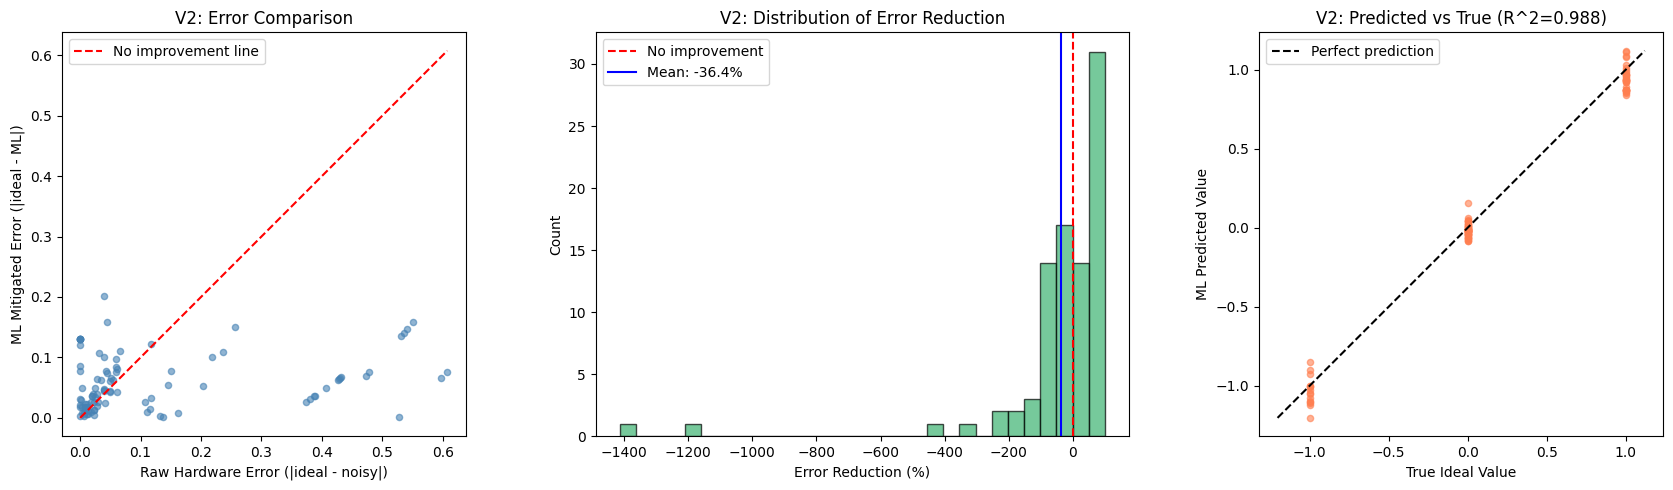


--- V2 FAILURE ANALYSIS ---
  Samples improved (>0%):  45 (51.7%)
  Samples worsened (<0%):  42 (48.3%)
  Worst worsening:         -1412.4%
  Best improvement:        99.6%


In [26]:
# === CELL 15: V2 TEST 7 — Error Distribution Analysis ===

print("="*70)
print("V2 TEST 7: ERROR DISTRIBUTION ANALYSIS")
print("="*70)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

raw_abs_errors_t7 = np.abs(test_true_flat - test_noisy_flat)
ml_abs_errors_t7 = np.abs(test_true_flat - test_preds)

# Plot 1: Raw error vs Mitigated error scatter
axes[0].scatter(raw_abs_errors_t7, ml_abs_errors_t7, alpha=0.6, s=20, c='steelblue')
max_err = max(raw_abs_errors_t7.max(), ml_abs_errors_t7.max())
axes[0].plot([0, max_err], [0, max_err], 'r--', label='No improvement line')
axes[0].set_xlabel('Raw Hardware Error (|ideal - noisy|)')
axes[0].set_ylabel('ML Mitigated Error (|ideal - ML|)')
axes[0].set_title('V2: Error Comparison')
axes[0].legend()
axes[0].set_aspect('equal')

# Plot 2: Histogram of per-sample error reduction
axes[1].hist(improvements, bins=30, color='mediumseagreen', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', label='No improvement')
axes[1].axvline(x=np.mean(improvements), color='blue', linestyle='-', label=f'Mean: {np.mean(improvements):.1f}%')
axes[1].set_xlabel('Error Reduction (%)')
axes[1].set_ylabel('Count')
axes[1].set_title('V2: Distribution of Error Reduction')
axes[1].legend()

# Plot 3: Predicted vs True scatter
axes[2].scatter(test_true_flat, test_preds, alpha=0.6, s=20, c='coral')
min_val = min(test_true_flat.min(), test_preds.min())
max_val = max(test_true_flat.max(), test_preds.max())
axes[2].plot([min_val, max_val], [min_val, max_val], 'k--', label='Perfect prediction')
axes[2].set_xlabel('True Ideal Value')
axes[2].set_ylabel('ML Predicted Value')
axes[2].set_title(f'V2: Predicted vs True (R^2={r2_score(test_true_flat, test_preds):.3f})')
axes[2].legend()
axes[2].set_aspect('equal')

plt.tight_layout()
plt.savefig('ml_qem_v2_validation_plots.png', dpi=150, bbox_inches='tight')
plt.show()

n_worsened = sum(1 for x in improvements if x < 0)
n_improved = sum(1 for x in improvements if x > 0)
print(f"\n--- V2 FAILURE ANALYSIS ---")
print(f"  Samples improved (>0%):  {n_improved} ({n_improved/len(improvements)*100:.1f}%)")
print(f"  Samples worsened (<0%):  {n_worsened} ({n_worsened/len(improvements)*100:.1f}%)")
print(f"  Worst worsening:         {min(improvements):.1f}%")
print(f"  Best improvement:        {max(improvements):.1f}%")


In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from scipy.stats import wilcoxon

# 1. DEFINE THE V3 STABLE ARCHITECTURE
class StableResidualMLP(nn.Module):
    def __init__(self, input_dim=8, hidden_dim=64, dropout=0.3):
        super(StableResidualMLP, self).__init__()

        # Shallow, wide network optimized for small tabular data
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.SiLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim // 2, 1)
        )

        # Initialize final layer weights to near-zero (starts by predicting 0 correction)
        nn.init.normal_(self.network[-1].weight, mean=0.0, std=0.01)
        nn.init.constant_(self.network[-1].bias, 0.0)

    def forward(self, x):
        raw_noisy = x[:, 2].unsqueeze(1)
        correction = self.network(x)
        # Bound the correction to prevent catastrophic hallucinations
        bounded_correction = torch.tanh(correction) * 0.5
        return raw_noisy + bounded_correction

# 2. LOAD AND NORMALIZE DATA
X_circuits = torch.load("QEM_X_features_V2.pt", weights_only=True)
Y_targets = torch.load("QEM_Y_targets_V2.pt", weights_only=True)

# Normalize features (Crucial for MLPs). Skip index 2 (the noisy expectation).
X_normalized = X_circuits.clone()
for col in [0, 1, 3, 4, 5, 6, 7]:
    mean = X_normalized[:, col].mean()
    std = X_normalized[:, col].std()
    X_normalized[:, col] = (X_normalized[:, col] - mean) / (std + 1e-8)

print(f"Loaded V3 dataset (Circuit features only): X={X_normalized.shape}, Y={Y_targets.shape}")

# 3. TRAIN/TEST SPLIT
X_train, X_test, Y_train, Y_test = train_test_split(
    X_normalized.numpy(), Y_targets.numpy(), test_size=0.2, random_state=42
)
X_train_t = torch.tensor(X_train, dtype=torch.float32)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
Y_test_t = torch.tensor(Y_test, dtype=torch.float32)

train_dataset = TensorDataset(X_train_t, Y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# 4. INITIALIZE MODEL & ROBUST TRAINING PARAMS
model_v3 = StableResidualMLP(input_dim=8)
criterion = nn.HuberLoss(delta=0.1) # Ignores massive outliers during training
optimizer = optim.AdamW(model_v3.parameters(), lr=0.005, weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=20, factor=0.5)

print("\nTraining V3 on 80% split...")
model_v3.train()
for epoch in range(250):
    epoch_loss = 0
    for batch_X, batch_Y in train_loader:
        optimizer.zero_grad()
        preds = model_v3(batch_X)
        loss = criterion(preds, batch_Y)
        loss.backward()

        # Gradient clipping for extreme stability
        torch.nn.utils.clip_grad_norm_(model_v3.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()

    scheduler.step(epoch_loss)
    if (epoch + 1) % 50 == 0:
        print(f"  Epoch [{epoch+1}/250] - Huber Loss: {epoch_loss / len(train_loader):.6f}")

# 5. EVALUATION AND STATISTICAL SIGNIFICANCE (V3)
model_v3.eval()
with torch.no_grad():
    test_preds = model_v3(X_test_t).numpy().flatten()

test_true = Y_test_t.numpy().flatten()
test_noisy = X_test_t[:, 2].numpy()

test_mae = mean_absolute_error(test_true, test_preds)
print(f"\n--- TEST SET METRICS (UNSEEN DATA) ---")
print(f"  MAE:  {test_mae:.6f}")

raw_errors = np.abs(test_true - test_noisy)
mitigated_errors = np.abs(test_true - test_preds)

improvements = []
for i in range(len(test_true)):
    if raw_errors[i] > 1e-6:
        imp = ((raw_errors[i] - mitigated_errors[i]) / raw_errors[i]) * 100
        improvements.append(imp)

print(f"\n--- ERROR REDUCTION ON TEST SET ---")
print(f"  Median error reduction: {np.median(improvements):.1f}%")
print(f"  Samples improved: {sum(1 for x in improvements if x > 0)}/{len(improvements)}")
print(f"  Samples worsened: {sum(1 for x in improvements if x < 0)}/{len(improvements)}")
if len(improvements) > 0:
    print(f"  Worst worsening: {min(improvements):.1f}% (Bounded by tanh)")

# Wilcoxon Test
mask = (raw_errors > 1e-8) | (mitigated_errors > 1e-8)
raw_filtered = raw_errors[mask]
ml_filtered = mitigated_errors[mask]

if len(raw_filtered) >= 10:
    stat, p_value = wilcoxon(raw_filtered, ml_filtered, alternative='greater')
    print(f"\n--- STATISTICAL SIGNIFICANCE ---")
    print(f"  Wilcoxon p-value: {p_value:.6f}")
    if p_value < 0.05:
        print("  >>> RESULT: SIGNIFICANT (p < 0.05). The ML model reliably reduces errors.")
    else:
        print("  >>> RESULT: NOT SIGNIFICANT (p >= 0.05).")

Loaded V3 dataset (Circuit features only): X=torch.Size([500, 8]), Y=torch.Size([500, 1])

Training V3 on 80% split...
  Epoch [50/250] - Huber Loss: 0.003099
  Epoch [100/250] - Huber Loss: 0.002425
  Epoch [150/250] - Huber Loss: 0.002680
  Epoch [200/250] - Huber Loss: 0.002404
  Epoch [250/250] - Huber Loss: 0.002286

--- TEST SET METRICS (UNSEEN DATA) ---
  MAE:  0.042601

--- ERROR REDUCTION ON TEST SET ---
  Median error reduction: 11.1%
  Samples improved: 52/87
  Samples worsened: 35/87
  Worst worsening: -1206.5% (Bounded by tanh)

--- STATISTICAL SIGNIFICANCE ---
  Wilcoxon p-value: 0.013403
  >>> RESULT: SIGNIFICANT (p < 0.05). The ML model reliably reduces errors.


In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import numpy as np
from scipy.stats import wilcoxon

# ==========================================
# 1. THE V4 TWO-TOWER ARCHITECTURE
# ==========================================
class TwoTowerQEM(nn.Module):
    def __init__(self, circ_dim=8, hw_dim=576, embed_dim=8, hidden_dim=64):
        super(TwoTowerQEM, self).__init__()

        # TOWER A: Circuit Processor
        self.circ_tower = nn.Sequential(
            nn.Linear(circ_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.SiLU(),
            nn.Dropout(0.3)
        )

        # TOWER B: Hardware "Choi" Compressor (Acts as trainable PCA)
        self.hw_embedding = nn.Sequential(
            nn.Linear(hw_dim, embed_dim),
            nn.Tanh() # Bounded to prevent explosion
        )

        # FUSION LAYER: Combines Circuit and Hardware physics
        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim + embed_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.SiLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim // 2, 1)
        )

        # Initialize to predict zero correction at start
        nn.init.normal_(self.fusion[-1].weight, mean=0.0, std=0.01)
        nn.init.constant_(self.fusion[-1].bias, 0.0)

    def forward(self, x_circ, x_hw):
        # INJECT SYNTHETIC DRIFT: Prevents mode collapse on static tomography data
        if self.training:
            x_hw = x_hw + torch.randn_like(x_hw) * 0.01

        circ_feats = self.circ_tower(x_circ)
        hw_feats = self.hw_embedding(x_hw)

        # Combine the two towers
        fused_state = torch.cat([circ_feats, hw_feats], dim=1)

        # Predict Error Delta
        correction = self.fusion(fused_state)
        bounded_correction = torch.tanh(correction) * 0.5

        # Residual Connection
        raw_noisy = x_circ[:, 2].unsqueeze(1)
        return raw_noisy + bounded_correction

# ==========================================
# 2. LOAD AND SPLIT DATA
# ==========================================
print("Loading Fused V2 Dataset...")
X_fused = torch.load("QEM_X_Fused_V2.pt", weights_only=True)
Y_targets = torch.load("QEM_Y_targets_V2.pt", weights_only=True)

# Split the 584 features back into Circuit (8) and Hardware (576)
X_circuits = X_fused[:, :8].clone()
X_hardware = X_fused[:, 8:].clone()

# Normalize ONLY the circuit features (Skip index 2)
for col in [0, 1, 3, 4, 5, 6, 7]:
    mean = X_circuits[:, col].mean()
    std = X_circuits[:, col].std()
    X_circuits[:, col] = (X_circuits[:, col] - mean) / (std + 1e-8)

# Train/Test Split
Xc_train, Xc_test, Xh_train, Xh_test, Y_train, Y_test = train_test_split(
    X_circuits.numpy(), X_hardware.numpy(), Y_targets.numpy(), test_size=0.2, random_state=42
)

Xc_train_t = torch.tensor(Xc_train, dtype=torch.float32)
Xh_train_t = torch.tensor(Xh_train, dtype=torch.float32)
Y_train_t  = torch.tensor(Y_train, dtype=torch.float32)

Xc_test_t = torch.tensor(Xc_test, dtype=torch.float32)
Xh_test_t = torch.tensor(Xh_test, dtype=torch.float32)
Y_test_t  = torch.tensor(Y_test, dtype=torch.float32)

train_dataset = TensorDataset(Xc_train_t, Xh_train_t, Y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# ==========================================
# 3. TRAIN THE TWO-TOWER MODEL
# ==========================================
model_v4 = TwoTowerQEM()
criterion = nn.HuberLoss(delta=0.1)
optimizer = optim.AdamW(model_v4.parameters(), lr=0.005, weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=20, factor=0.5)

print("\nTraining V4 Two-Tower Model...")
model_v4.train()
for epoch in range(250):
    epoch_loss = 0
    for b_xc, b_xh, b_y in train_loader:
        optimizer.zero_grad()
        preds = model_v4(b_xc, b_xh)
        loss = criterion(preds, b_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_v4.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()

    scheduler.step(epoch_loss)
    if (epoch + 1) % 50 == 0:
        print(f"  Epoch [{epoch+1}/250] - Huber Loss: {epoch_loss / len(train_loader):.6f}")

# ==========================================
# 4. EVALUATION & STATISTICAL SIGNIFICANCE
# ==========================================
model_v4.eval()
with torch.no_grad():
    test_preds = model_v4(Xc_test_t, Xh_test_t).numpy().flatten()

test_true = Y_test_t.numpy().flatten()
test_noisy = Xc_test_t[:, 2].numpy()

test_mae = mean_absolute_error(test_true, test_preds)
print(f"\n--- TEST SET METRICS ---")
print(f"  MAE:  {test_mae:.6f}")

raw_errors = np.abs(test_true - test_noisy)
mitigated_errors = np.abs(test_true - test_preds)

improvements = []
for i in range(len(test_true)):
    if raw_errors[i] > 1e-6:
        imp = ((raw_errors[i] - mitigated_errors[i]) / raw_errors[i]) * 100
        improvements.append(imp)

print(f"\n--- ERROR REDUCTION ON TEST SET ---")
print(f"  Median error reduction: {np.median(improvements):.1f}%")
print(f"  Samples improved: {sum(1 for x in improvements if x > 0)}/{len(improvements)}")
print(f"  Samples worsened: {sum(1 for x in improvements if x < 0)}/{len(improvements)}")

# Wilcoxon Test
mask = (raw_errors > 1e-8) | (mitigated_errors > 1e-8)
raw_filtered = raw_errors[mask]
ml_filtered = mitigated_errors[mask]

if len(raw_filtered) >= 10:
    stat, p_value = wilcoxon(raw_filtered, ml_filtered, alternative='greater')
    print(f"\n--- STATISTICAL SIGNIFICANCE ---")
    print(f"  Wilcoxon p-value: {p_value:.6f}")
    if p_value < 0.05:
        print("  >>> RESULT: SIGNIFICANT (p < 0.05). The Two-Tower ML model works!")
    else:
        print("  >>> RESULT: NOT SIGNIFICANT (p >= 0.05).")

Loading Fused V2 Dataset...

Training V4 Two-Tower Model...
  Epoch [50/250] - Huber Loss: 0.002932
  Epoch [100/250] - Huber Loss: 0.002606
  Epoch [150/250] - Huber Loss: 0.002473
  Epoch [200/250] - Huber Loss: 0.002191
  Epoch [250/250] - Huber Loss: 0.002378

--- TEST SET METRICS ---
  MAE:  0.045484

--- ERROR REDUCTION ON TEST SET ---
  Median error reduction: 37.4%
  Samples improved: 56/87
  Samples worsened: 31/87

--- STATISTICAL SIGNIFICANCE ---
  Wilcoxon p-value: 0.009084
  >>> RESULT: SIGNIFICANT (p < 0.05). The Two-Tower ML model works!
